# Stock Portfolio Risk & Return Analysis

### Question: Given a set of stocks across different sectors, what is the historical risk-return profile of each and what portfolio allocation would have minimized risk for an expected return over the past 5 year period?

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

returns = pd.read_csv("daily_returns.csv", index_col=0, parse_dates=True)
cumulative = pd.read_csv("cumulative_returns.csv", index_col=0, parse_dates=True)

BENCHMARK = "SPY"

## Chart 1 - Growth of \\$1 invested:
#### Each line shows the value of \\$1 invested on day one of analysis, compounded daily, converting an abstract percentage to a dollar value for non-technical viewers.

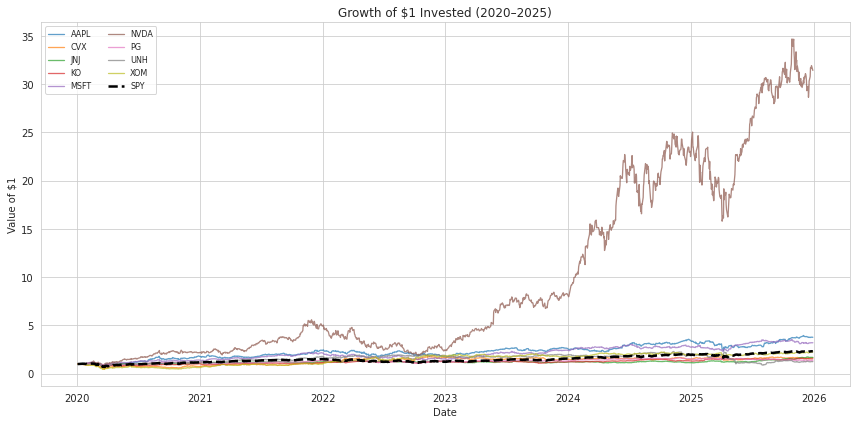

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

for ticker in cumulative.columns:
    if ticker == BENCHMARK:
        continue
    ax.plot(cumulative.index, cumulative[ticker], label=ticker, alpha=0.7, linewidth=1.3)

# Draw benchmark last, on top, styled distinctly
ax.plot(cumulative.index, cumulative[BENCHMARK], label=BENCHMARK,
        color="black", linewidth=2.5, linestyle="--")

ax.set_title("Growth of $1 Invested (2020–2025)")
ax.set_xlabel("Date")
ax.set_ylabel("Value of $1")
ax.legend(loc="upper left", ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig("fig_growth_of_1.png", dpi=150)
plt.show()

## Chart 2 - Annualized Return vs. Annualized Volatility:
#### Scatter plot to visualize the best return per unit of risk taken - high return, low volatility rating is more attractive than a higher raw return with high volatility.

In [7]:
ann_return = returns.mean() * 252
ann_vol = returns.std() * (252 ** 0.5)
sharpe = ann_return / ann_vol #using a simplified, risk free rate of 0

risk_return = pd.DataFrame({
    "ann_return": ann_return,
    "ann_vol": ann_vol,
    "sharpe": sharpe
}).sort_values("sharpe", ascending=False)

risk_return.to_csv("risk_return_summary.csv")
risk_return

,ann_return,ann_vol,sharpe
NVDA,0.717911,0.532014,1.349421
AAPL,0.272517,0.318192,0.856453
MSFT,0.238145,0.295549,0.805771
SPY,0.161555,0.207525,0.778488
XOM,0.189939,0.328183,0.578761
JNJ,0.105925,0.196587,0.538822
KO,0.092047,0.202940,0.453567
CVX,0.140922,0.339665,0.414884
PG,0.072133,0.206117,0.349961
UNH,0.094834,0.334533,0.283481


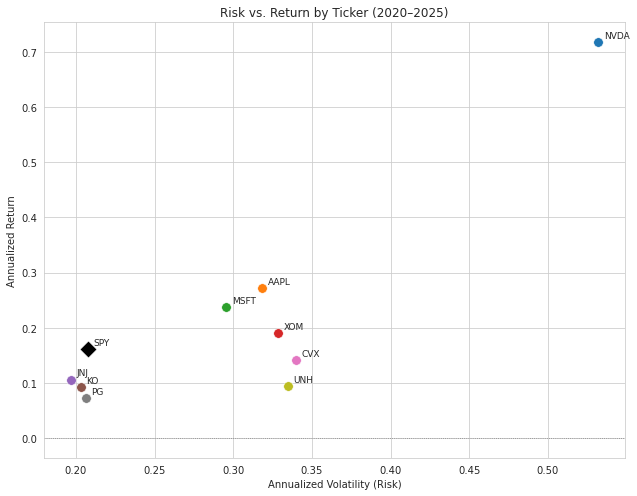

In [9]:
fig, ax = plt.subplots(figsize=(9, 7))

for ticker in risk_return.index:
    is_benchmark = ticker == BENCHMARK
    ax.scatter(
        risk_return.loc[ticker, "ann_vol"],
        risk_return.loc[ticker, "ann_return"],
        s=140 if is_benchmark else 90,
        color="black" if is_benchmark else None,
        marker="D" if is_benchmark else "o",
        zorder=3 if is_benchmark else 2,
        edgecolor="white",
        linewidth=0.5
    )
    ax.annotate(ticker,
                (risk_return.loc[ticker, "ann_vol"], risk_return.loc[ticker, "ann_return"]),
                xytext=(6, 4), textcoords="offset points", fontsize=9)

ax.set_xlabel("Annualized Volatility (Risk)")
ax.set_ylabel("Annualized Return")
ax.set_title("Risk vs. Return by Ticker (2020–2025)")
ax.axhline(0, color="grey", linewidth=0.8, linestyle=":")
plt.tight_layout()
plt.savefig("fig_risk_return_scatter.png", dpi=150)
plt.show()

## Chart 3 - Correlation Heatmap:
#### Low correlation between stocks is what produces the benefit of diversification - do stocks within the same sector move together, and do sectors move independently of each other?

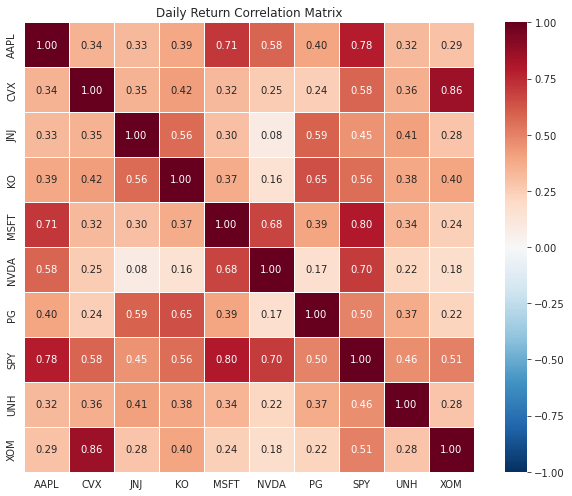

In [10]:
corr = returns.corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title("Daily Return Correlation Matrix")
plt.tight_layout()
plt.savefig("fig_correlation_heatmap.png", dpi=150)
plt.show()

corr.to_csv("correlation_matrix.csv")

## Chart 4 - Rolling 30 day volatility:
#### Did risk spike during any particular period around known market stress events, such as the crash in March 2020?

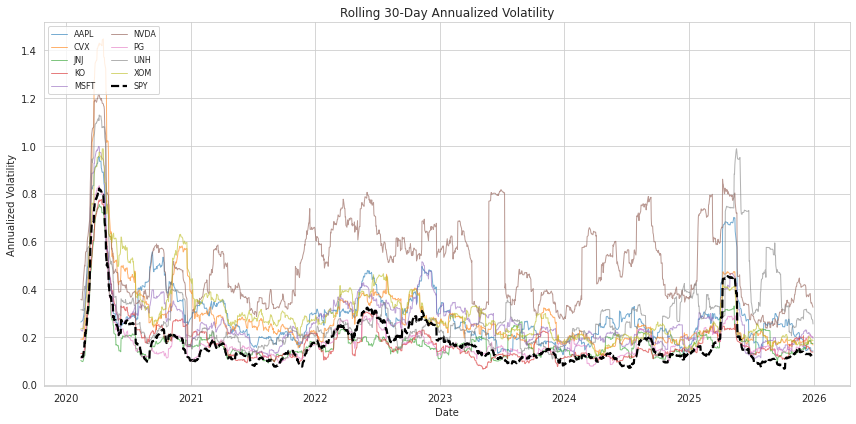

In [11]:
rolling_vol = returns.rolling(window=30).std() * (252 ** 0.5)

fig, ax = plt.subplots(figsize=(12, 6))
for ticker in rolling_vol.columns:
    if ticker == BENCHMARK:
        continue
    ax.plot(rolling_vol.index, rolling_vol[ticker], alpha=0.6, linewidth=1, label=ticker)

ax.plot(rolling_vol.index, rolling_vol[BENCHMARK], label=BENCHMARK,
        color="black", linewidth=2.2, linestyle="--")

ax.set_title("Rolling 30-Day Annualized Volatility")
ax.set_xlabel("Date")
ax.set_ylabel("Annualized Volatility")
ax.legend(loc="upper left", ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig("fig_rolling_volatility.png", dpi=150)
plt.show()

rolling_vol.to_csv("rolling_volatility_30d.csv")

## Chart 5 - Max Drawdown per ticker:
#### What's the worst peak to trough loss on each asset at the worst possible time? This is to capture a worst case scenario rather than an average measure of day to day fluctuations.

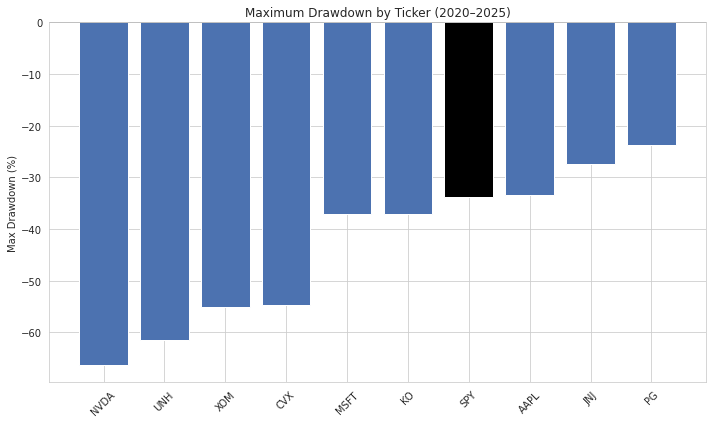

In [12]:
rolling_max = cumulative.cummax()
drawdown = (cumulative - rolling_max) / rolling_max
max_drawdown = drawdown.min().sort_values()

max_drawdown.to_csv("max_drawdown.csv", header=["max_drawdown"])

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["black" if t == BENCHMARK else "#4C72B0" for t in max_drawdown.index]
ax.bar(max_drawdown.index, max_drawdown.values * 100, color=colors)
ax.set_title("Maximum Drawdown by Ticker (2020–2025)")
ax.set_ylabel("Max Drawdown (%)")
ax.axhline(0, color="grey", linewidth=0.8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("fig_max_drawdown.png", dpi=150)
plt.show()

## Findings:
#### Of the sample, NVDA had the strongest $1 growth and the highest Sharpe ratio over 2020–2025, but also had the highest volatility from 2021 through mid-2025. It also had the deepest max drawdown, showing the classic risk-return tradeoff. Every stock of the sample showed a volatility spike in early 2020, consistent with the market crash of the COVID-19 pandemic. Correlation results show a clear sector story: energy peers CVX and XOM were the most correlated pair (0.86), while MSFT and AAPL each tracked SPY closely (0.80 and 0.78 respectively). NVDA was the best diversifier of the sample, showing the lowest correlations to defensive stock names (JNJ: 0.08, KO: 0.16, PG: 0.17). This shows that despite its volatility, adding it to a portfolio of defensive stocks would reduce overall portfolio risk rather than add to it.